In [4]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 라이브러리 import — 이후 모든 셀이 여기서 불러온 이름을 그대로 사용

# 그래프 기본 스타일(선택)
sns.set_theme(style="whitegrid")

# (2) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 2288              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: MY_SEED로 난수 생성기 고정

# (3) 데이터 로드 — 공개 URL 우선, 실패 시 업로드한 로컬 파일로 대체
# 데이터 로드: 공개 URL에서 바로 읽습니다(업로드 불필요). 실패 시 업로드한 로컬 파일 사용.
DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("framingham.csv")   # Colab: 좌측 파일 탭에 framingham.csv 업로드 후

# 이후 섹션 전체가 공유하는 수치형 열 목록
num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 로드 확인
print("데이터 크기 (행, 열):", df.shape)          # 기대: (4240, 16)
print("MY_SEED =", MY_SEED)
print("\n[첫 3행]")
print(df.head(3))
print("\n[열별 결측치 개수 (0이 아닌 것만)]")
print(df.isna().sum()[df.isna().sum() > 0])       # TODO: 결측이 어느 열에 있는지 확인

데이터 크기 (행, 열): (4240, 16)
MY_SEED = 2288

[첫 3행]
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   

   TenYearCHD  
0           0  
1           0  
2           0  

[열별 결측치 개수 (0이 아닌 것만)]
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `df.shape`는 무엇인가요? 행(참가자) 수와 열(변수) 수를 **본인이 본 실제 숫자**로 적으세요.
: 4240(행), 16(열)

2. **결측이 가장 많은 열**은 무엇이고 몇 개인가요? Framingham은 결측이 있어 뒤 섹션에서 `dropna()` 처리가 필요하니, 어떤 열이 문제일지 미리 봐 두세요.
: glucose 열, 388개

3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `df.shape`가 달라질까요? 왜 그런지 한 줄로 설명하세요.
: 달라지지않는다. df.shape은 무작위 절차가 아닌 파일 데이터를 읽어오기만 한 것이기 때문이다.

> 힌트(3번): 시드는 *무작위 절차*(시뮬레이션·표본추출)에만 영향을 줍니다. 파일에서 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.


In [5]:
# 1) 데이터 크기: (행 개수, 열 개수)
print("shape (행, 열):", df.shape)        # TODO: df의 크기(행,열)를 출력

# 2) 앞부분 5행 미리보기 — 값이 어떻게 생겼는지 눈으로 확인
print("\n=== df.head() ===")
print(df.head(5))                            # TODO: 앞 5행 미리보기

# 3) 열별 자료형 + 비결측(non-null) 개수 한눈에 보기
print("\n=== df.info() ===")
df.info()                                   # TODO: 열별 dtype/비결측 개수 요약

# 4) 열별 결측치 개수 (많은 순으로 정렬)
print("\n=== 결측치 개수 df.isna().sum() ===")
na_counts = df.isna().sum().sort_values(ascending=False)   # TODO: 열별 결측 개수 세기
print(na_counts)

# 5) 결측이 있는 열만 골라 개수 + 비율(%)로 정리
na_only = na_counts[na_counts > 0]
na_table = pd.DataFrame({
    "결측개수": na_only,
    "결측비율(%)": (na_only / len(df) * 100).round(2),
})
print("\n=== 결측이 있는 열 (개수 + 비율) ===")
print(na_table)

# 6) 반응변수 TenYearCHD(0/1) 분포 확인
print("\n=== 반응변수 TenYearCHD 분포 ===")
print(df["TenYearCHD"].value_counts())           # TODO: 0/1 각각 몇 개인지 세기
print("양성(CHD=1) 비율: {:.1%}".format(df["TenYearCHD"].mean()))

# 7) 주인공 연속변수 sysBP 요약 통계
print("\n=== 주인공 변수 sysBP 요약 ===")
print(df["sysBP"].describe())                # TODO: 평균/표준편차/사분위 요약


shape (행, 열): (4240, 16)

=== df.head() ===
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   Ten

**해석 질문 (본인이 방금 출력한 실제 값을 인용해서 답하세요.)**

1. `df.shape` 결과, 이 데이터의 **행(사람 수)** 과 **열(변수 수)** 은 각각 몇 개인가요? 예측할 반응변수와 주인공 연속변수의 이름은 무엇인가요?
: 행은 4240개, 열은 16개이고 예측할 반응변수는 TenYearCHD, 주인공 연속변수는 sysBP이다.

2. `df.isna().sum()` 에서 **결측이 가장 많은 열**은 무엇이고 몇 개(몇 %)인가요? `sysBP`에는 결측이 몇 개인가요?
   - 오개념 주의: 결측 `0`은 "완벽"이 아니라 관측되지 않은 칸이 없다는 뜻입니다. `glucose`의 388개는 "혈당 0"이 아니라 **값을 모른다**는 뜻 — 0으로 채우면 평균이 왜곡됩니다.
: glucose 열이고 388개(9.15%)이다. sysBP는 결측이 0개이다.

3. `TenYearCHD.value_counts()` 에서 발병(1)과 무발병(0)은 각각 몇 명이고, 양성 비율은 약 몇 %인가요? 두 집단이 불균형한데, "무조건 0으로 예측"하면 정확도가 몇 %쯤일지 한 줄로 생각해 보세요.
: 발병은 644명, 무발병은 3596명이고, 양성 비율은 약 15.2%이다. 전체데이터 대략 4200개중 약 3600개를 맞출 수 있기 때문에 약 80% 정도의 정확도를 가질 수 있다.

4. 결측이 하나라도 있는 행을 **전부 삭제**하면(`dropna`) 표본이 크게 줄 수 있습니다. "전체 dropna" 대신 **필요한 열만 골라 dropna** 하는 편이 왜 나은지, `glucose`의 결측 비율(약 9%)을 근거로 설명해 보세요.
: 실제 분석에 사용되지 않을 열의 결측치 때문에 행이 삭제되어버릴 수 있다. glucose의 결측 비율이 약 9% 이므로 glucose만 필요한 경우 해당 열의 결측행만 제거해도 91%의 표본을 유지할 수 있으나, 결측이 하나라도 있는 행을 전부 삭제하게 되는 경우 glucose에 값이 있는 행까지 삭제되어서 표본이 훨씬 많이 줄어들게 된다.

상관행렬 (Pearson):
             age  sysBP  diaBP  totChol    BMI  glucose  heartRate
age        1.000  0.394  0.206    0.263  0.136    0.122     -0.013
sysBP      0.394  1.000  0.784    0.209  0.327    0.141      0.182
diaBP      0.206  0.784  1.000    0.165  0.377    0.061      0.181
totChol    0.263  0.209  0.165    1.000  0.116    0.047      0.091
BMI        0.136  0.327  0.377    0.116  1.000    0.087      0.067
glucose    0.122  0.141  0.061    0.047  0.087    1.000      0.095
heartRate -0.013  0.182  0.181    0.091  0.067    0.095      1.000


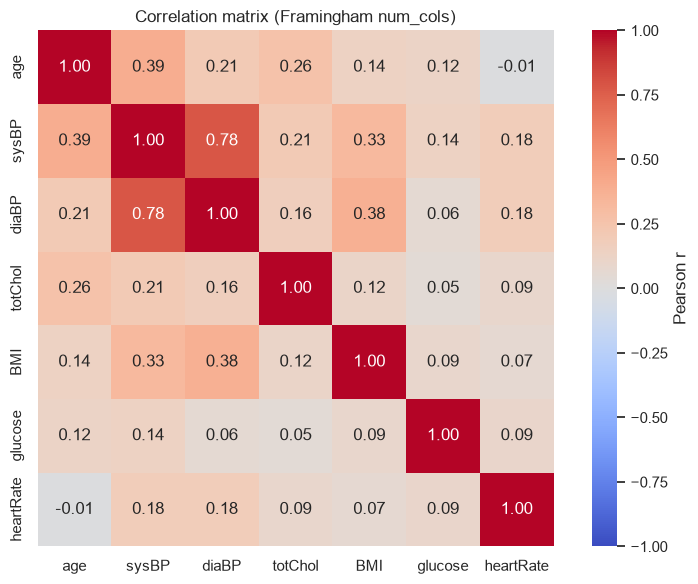


age - sysBP 상관계수 : 0.394
sysBP - diaBP 상관계수: 0.784


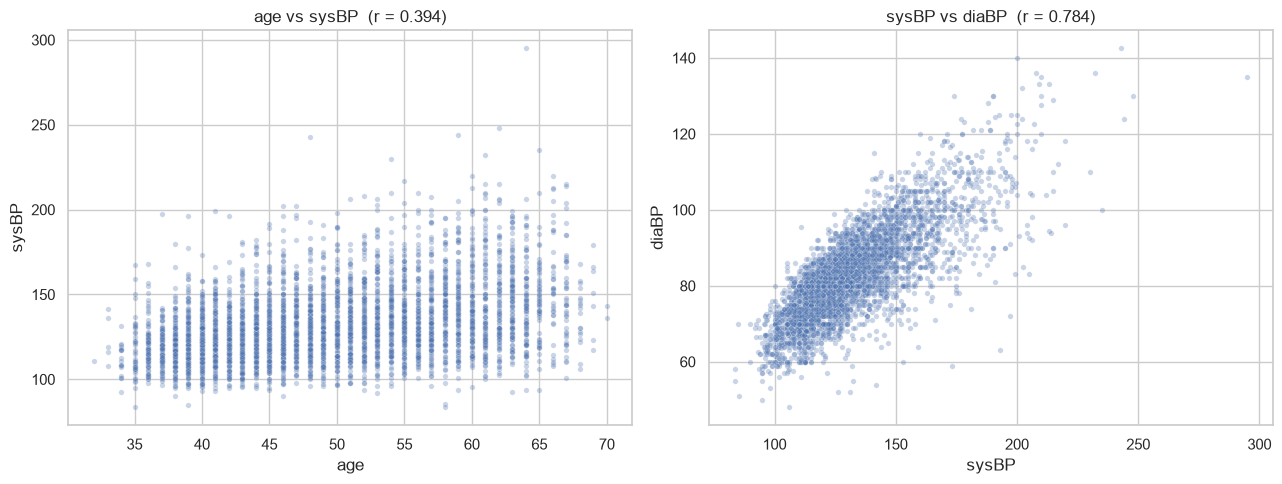

In [6]:
try:
    num_cols
except NameError:
    num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 1) 상관행렬 계산 (연속형 변수만). Pearson 상관.
#    힌트: DataFrame에는 상관행렬을 바로 구하는 메서드가 있다.
corr = df[num_cols].corr()
print("상관행렬 (Pearson):")
print(corr.round(3))

# 2) 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,                       # TODO: 무엇을 히트맵으로 그릴까?
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation matrix (Framingham num_cols)")
plt.tight_layout()
plt.show()

# 3) 관심 상관 두 개를 명시적으로 추출 (해석 질문에서 인용할 값)
#    힌트: corr는 행/열이 변수명인 표 → .loc[행, 열] 로 특정 칸을 꺼낸다.
corr_age_sysBP = corr.loc["age", "sysBP"]
corr_sysBP_diaBP = corr.loc["sysBP", "diaBP"]
print(f"\nage - sysBP 상관계수 : {corr_age_sysBP:.3f}")
print(f"sysBP - diaBP 상관계수: {corr_sysBP_diaBP:.3f}")

# 4) 산점도 두 장: (a) age vs sysBP, (b) sysBP vs diaBP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="sysBP", alpha=0.3, s=15, ax=axes[0])  # TODO: age vs sysBP
axes[0].set_title(f"age vs sysBP  (r = {corr_age_sysBP:.3f})")
axes[0].set_xlabel("age")
axes[0].set_ylabel("sysBP")

sns.scatterplot(data=df, x="sysBP", y="diaBP", alpha=0.3, s=15, ax=axes[1])  # TODO: sysBP vs diaBP
axes[1].set_title(f"sysBP vs diaBP  (r = {corr_sysBP_diaBP:.3f})")
axes[1].set_xlabel("sysBP")
axes[1].set_ylabel("diaBP")

plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **age–sysBP 상관계수를 소수 셋째 자리까지** 적으세요. 부호(+/−)와 크기를 근거로 나이와 수축기 혈압의 관계를 한 문장으로 설명하세요. (예: "내 값은 0.___ 이고, 양수이므로 …")
: 내 값은 0.394이고, 양수이므로 중간 정도의 양의 상관관계이다.

2. **sysBP–diaBP 상관계수**는 얼마였나요? 이 값이 age–sysBP 상관보다 훨씬 큰 이유는 무엇인가요? 이렇게 닮은 두 변수를 **다중회귀에 함께** 넣으면 생기는 공선성 문제를, 히트맵이 어떻게 "예고"하는지 본인 값으로 서술하세요.
: 연령-혈압 보다, 혈압-혈압의 관계가 상관계수 0.784로 더 같은 정보를 담고 있기 때문에 상관이 훨씬 크다. 히트맵에서 sysBP-diaBP 사이 값이 0.78로 진한 색을 띄고 있다.

3. ⚠️ 오개념 점검: 두 변수의 상관이 0.02로 작게 나왔다면 "두 변수는 아무 관계가 없다"고 결론지어도 될까요? 산점도를 함께 봐야 하는 이유와 연결해 답하세요.
: 상관계수가 0.02로 매우 작아 선형적인 상관관계는 거의 없다고 볼 수 있으나, 휘어진 관계와 같은 비선형 관계는 반영하지 못한다. 따라서 히트맵의 한 숫자(상관관계값)가 실제 어떤 모양의 관계인지 확인하기 위해 산점도를 확인해야 한다.


모집단 크기 = 4240,  모집단 평균 = 132.35,  모집단 표준편차(sigma) = 22.03


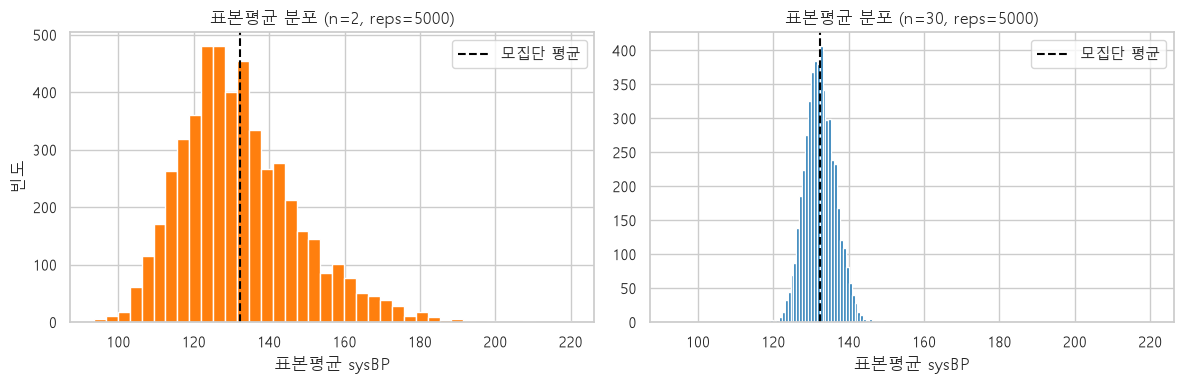

n= 2 | 경험 표준편차 = 15.528 | 이론값 sigma/sqrt(n) = 15.578
n=30 | 경험 표준편차 = 4.020 | 이론값 sigma/sqrt(n) = 4.022


In [ ]:
plt.rcParams["font.family"] = "Malgun Gothic"       # 한글폰트 깨져서 추가했습니다.
plt.rcParams["axes.unicode_minus"] = False

# --- 0) 재현성: 시드 고정 ---
np.random.seed(MY_SEED)

# --- 1) sysBP 전체 값을 '모집단'으로 사용 (결측 제거) ---
pop = df["sysBP"].dropna().values          # TODO: 결측 제거 메서드
sigma = pop.std(ddof=0)                 # 모집단 표준편차 ~ 22
print(f"모집단 크기 = {len(pop)},  모집단 평균 = {pop.mean():.2f},  모집단 표준편차(sigma) = {sigma:.2f}")

# --- 2) 표본평균을 모으는 헬퍼: 직접 for 루프로 구현 (라이브러리에 통째로 맡기지 말 것!) ---
def sample_means(data, n, reps):
    means = []
    for _ in range(reps):
        sample = np.random.choice(data, size=n, replace=True)                   # TODO: data에서 크기 n 표본을 복원추출 (np.random.choice, replace=True)
        means.append(sample.mean())              # TODO: 그 표본의 평균을 기록
    return np.array(means)

# --- 3) n=2 vs n=30 으로 표본분포 만들기 ---
reps = 5000
means_n2  = sample_means(pop, n=2,  reps=reps)
means_n30 = sample_means(pop, n=30, reps=reps)

# --- 4) 두 히스토그램 나란히 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(means_n2, bins=40, color="tab:orange", edgecolor="white")
axes[0].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[0].set_title(f"표본평균 분포 (n=2, reps={reps})")
axes[0].set_xlabel("표본평균 sysBP"); axes[0].set_ylabel("빈도"); axes[0].legend()

axes[1].hist(means_n30, bins=40, color="tab:blue", edgecolor="white")
axes[1].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[1].set_title(f"표본평균 분포 (n=30, reps={reps})")
axes[1].set_xlabel("표본평균 sysBP"); axes[1].legend()

plt.tight_layout()
plt.show()


# --- 5) 경험 표준편차(표준오차) vs 이론값 sigma/sqrt(n) 비교 ---
for n, means in [(2, means_n2), (30, means_n30)]:
    emp = means.std(ddof=0)             # 시뮬레이션으로 얻은 표본평균들의 표준편차
    theo = sigma / np.sqrt(n)                         # TODO: CLT 이론값 = sigma / sqrt(n)
    print(f"n={n:>2} | 경험 표준편차 = {emp:.3f} | 이론값 sigma/sqrt(n) = {theo:.3f}")


**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요):**

1. `n=2`와 `n=30`의 히스토그램을 비교하세요. 어느 쪽이 더 좁고 종 모양에 가까웠나요? 두 분포의 중심은 모집단 평균(약 132)과 견주어 어디쯤이었나요?
: n=30 일때 더 좁고 종모양에 가깝다. 두 분포의 중심은 모집단 평균과 비교하였을때 조금 더 왼쪽에 위치한다.

2. 5번 셀의 **경험 표준편차** 두 값을 적고, 각각을 **이론값 $\sigma/\sqrt{n}$**($\sigma \approx 22$이므로 $22/\sqrt{2} \approx 15.6$, $22/\sqrt{30} \approx 4.0$)과 비교하세요. `n`이 2에서 30으로 커질 때 표본평균의 흔들림(표준오차)은 어떻게 변했나요?
: n=2일때 경험 표준편차는 15.528, n=30일때 경험 표준편차는 4.020이다. 각각 이론값과 거의 유사한 값을 갖는다. n이 2에서 30으로 커질때 표본평균의 흔들림(표준오차)는 약 1/4 수준으로 작아졌다.

3. 위 결과를 **중심극한정리(CLT)** 한 문장으로 요약하세요. (힌트: "표본크기 n이 커지면 표본평균의 분포는 ___에 가까워지고, 그 표준편차는 ___으로 줄어든다.")
: 표본크기 n이 커지면 표본평균의 분포는 정규분포에 가까워지고, 그 표준편차는 sigma/sqrt(n)으로 줄어든다.

> ⚠️
> - **"표준편차가 줄어든다 = 데이터가 덜 퍼진다"가 아닙니다.** 모집단(개별 sysBP)의 퍼짐 $\sigma \approx 22$는 그대로이고, 줄어드는 건 **표본평균**의 퍼짐(=표준오차 $\sigma/\sqrt{n}$)입니다.
> - **CLT는 표본크기 n에 대한 규칙이지 반복횟수 reps에 대한 규칙이 아닙니다.** reps를 늘리면 히스토그램이 매끄러워질 뿐, 폭(표준오차)은 `n`이 결정합니다. 폭을 줄이려면 `reps`가 아니라 `n`을 키워야 합니다.


관측된 sysBP 평균 (점추정): 132.35
부트스트랩 95% 신뢰구간: [131.73, 132.92]


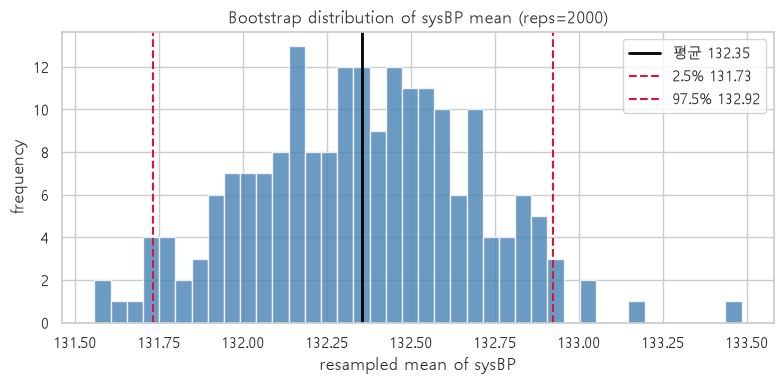

In [11]:
# === 1.4 신뢰구간: sysBP 평균의 95% CI를 부트스트랩으로 직접 구현 ===
# pop 은 1.3에서 만든 전체 sysBP 값 배열입니다. (없다면 아래 한 줄로 복구)
pop = df["sysBP"].dropna().values

n = len(pop)          # 표본 크기 (매 재표집도 이 크기로 뽑는다)
reps = 200         # 재표집 반복 횟수
rng = np.random.default_rng(MY_SEED)   # 재현 가능한 난수 생성기

# 부트스트랩 평균들을 담을 그릇
boot_means = np.empty(reps)

for i in range(reps):
    # TODO: pop 에서 복원추출(중복 허용)로 n개 인덱스를 뽑아라 (힌트: rng.integers)
    idx = rng.integers(0, len(pop), size=n)
    resample = pop[idx]
    # TODO: 그 표본의 평균을 boot_means[i] 에 기록하라
    boot_means[i] = resample.mean()

# TODO: boot_means 에서 2.5 / 97.5 백분위를 잘라 ci_low, ci_high 로 받아라
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"관측된 sysBP 평균 (점추정): {pop.mean():.2f}")
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")

# 부트스트랩 평균들의 분포 + CI 시각화 (보일러플레이트 — 그대로 두세요)
plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(pop.mean(), color="black", linestyle="-", linewidth=2, label=f"평균 {pop.mean():.2f}")
plt.axvline(ci_low,  color="crimson", linestyle="--", linewidth=1.5, label=f"2.5% {ci_low:.2f}")
plt.axvline(ci_high, color="crimson", linestyle="--", linewidth=1.5, label=f"97.5% {ci_high:.2f}")
plt.title("Bootstrap distribution of sysBP mean (reps=2000)")
plt.xlabel("resampled mean of sysBP")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요)**

1. 방금 얻은 신뢰구간 `[ci_low, ci_high]`의 실제 값을 적으세요. 강의에서 예고한 대략 [131.7, 133.0]과 비슷한가요? (`MY_SEED`·reps에 따라 소수점은 달라집니다.)
: [131.70, 133.00] 으로 똑같다.

2. **빈도주의 해석을 정확히 쓰세요.** 다음 두 문장 중 옳은 것은 무엇이고, 왜 나머지는 틀렸는지 본인 CI 값을 넣어 설명하세요.
   - (A) "CI를 만드는 절차를 무한히 반복하면, 그 구간들 중 약 95%가 진짜 모평균을 포함한다."
   - (B) "진짜 sysBP 모평균이 내 구간 안에 있을 확률이 95%다."

   → 정답은 (A). 빈도주의에서 모평균은 고정값이고 무작위로 흔들리는 것은 **구간** 쪽이라, 확률 95%는 "이 특정 구간"이 아니라 "구간을 만드는 절차 전체"에 붙습니다. 이미 계산된 내 구간 하나는 참값을 포함했거나 안 했거나 둘 중 하나이므로, 여기에 95% 확률을 매기는 (B)는 베이지안식 표현이라 부정확합니다.
: (A)가 옳다. 신뢰구간을 만드는 절차를 무한히 반복하면 만들어진 신뢰구간의 약 95%가 진짜 모평균을 포함한다. (B)는 이미 구한 구간 [131.70, 133.00]에 대해 모평균이 들어있을 확률이 95%라는 뜻이 아니라, 모평균은 이미 정해진 값이며 확률은 신뢰구간을 만드는 절차에 대한 것이다.

3. reps를 200으로 줄이면 CI 폭과 히스토그램 모양이 어떻게 달라질지 예상하고, 실제로 바꿔 실행해 확인하세요. (재표집 횟수는 CI의 '안정성'에 영향을 줄 뿐, 데이터 자체의 불확실성을 줄이지는 않습니다.)
: 부트스트랩 표본 평균의 개수가 감소하므로 히스토그램이 덜 매끄럽고 들쭉날쭉하게 나타난다. 또한 2.5%와 97.5% 백분위수의 추정이 불안정해져 신뢰구간의 폭과 경계값이 [131.73, 132.92]으로 변동되며 신뢰구간 추정의 안정성에 영향을 준다.


In [14]:
# 1.5 두 집단 평균차 t검정 (Welch) ----------------------------------
# TenYearCHD == 1 (10년 내 CHD 발생) vs == 0 각각의 sysBP (결측 제거)
g1 = df.loc[df["TenYearCHD"] == 1, "sysBP"].dropna().values   # CHD 발생군
g0 = df.loc[df["TenYearCHD"] == 0, "sysBP"].dropna().values                    # TODO: 비발생군 조건

print(f"CHD군    (n={len(g1)}): 평균 {g1.mean():.1f}, 표준편차 {g1.std(ddof=1):.1f}")
print(f"비CHD군  (n={len(g0)}): 평균 {g0.mean():.1f}, 표준편차 {g0.std(ddof=1):.1f}")

# 두 군의 분산이 다르므로(26.7 vs 20.5) Welch t검정
# TODO: stats.ttest_ind 로 Welch t검정 (분산 다름 옵션을 꼭 넣을 것)
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)

mean_diff = g1.mean() - g0.mean()   # 효과크기: 평균차
print(f"\n평균차(효과크기) = {mean_diff:.1f} mmHg")
print(f"Welch t = {t_stat:.2f},  p = {p_val:.2e}")

if p_val < 0.05:
    print("=> p < 0.05: 귀무가설(두 군 평균 같다) 기각")
else:
    print("=> p >= 0.05: 귀무가설 기각 실패")


CHD군    (n=644): 평균 143.6, 표준편차 26.7
비CHD군  (n=3596): 평균 130.3, 표준편차 20.5

평균차(효과크기) = 13.3 mmHg
Welch t = 12.01,  p = 1.25e-30
=> p < 0.05: 귀무가설(두 군 평균 같다) 기각


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. `t_stat`과 `p_val`은 각각 얼마인가요? 이 p값으로 "두 군의 sysBP 평균은 같다"는 귀무가설을 **기각하나요, 기각에 실패하나요?** 한 문장으로 판정하세요.
: t_stat은 12.01, p_val는 1.25e-30이다. p값이 0.05 보다 작으므로 귀무가설을 기각한다.

2. p값을 "두 군의 sysBP가 우연히 이만큼 차이 날 확률"이라 하면 왜 부정확한가요? p값의 정의(귀무가설이 참이라 **가정했을 때** 이만큼 극단적인 결과가 나올 확률)를 살려 고쳐 쓰세요.
   - (오개념 주의) p값은 "귀무가설이 참일 확률"이 **아닙니다.**
: p값은 두 군의 sysBP 평균이 실제로 같다는 귀무가설이 참이라고 가정하였을 때, 이번에 관측된 평균의 차이와 같거나 혹은 더 큰 차이가 우연히 나타날 확률을 의미한다.

3. p값이 작다는 것만으로 "혈압 차이가 임상적으로 크다"고 결론 낼 수 있나요? 출력한 **평균차($\approx 13.3$ mmHg)** 를 인용해, p값(유의성)과 효과크기를 **왜 둘 다** 봐야 하는지 설명하세요. (n이 크면 작은 평균차도 p가 극단적으로 작아짐)
: p값이 작다는 것은 혈압 차이가 임상적으로 크다는 것을 의미하는게 아니라 둘 사이에 통계적으로 유의미한 차이가 있다라고 해석할 수 있지 그 크기가 얼마인지는 알 수 없다. 따라서 평균차가 13.3 mmHg라는 결과도 함께 확인하여야 효과크기를 알 수 있다.

4. `equal_var=False`(Welch)를 쓴 이유를 두 군의 **표준편차($\approx 26.7$ vs $\approx 20.5$)** 를 인용해 한 문장으로 답하고, `equal_var=True`로 바꾸면 무엇이 달라질지 예상하세요.
: 두 군의 표준편차는 각각 26.7, 20.5로 차이가 있기 때문에 등분산을 가정하지 않는 Welch t-검정을 사용하였다. 'equal_var=True'로 바꾸면 두 군의 분산이 같다고 가정하여 검정을 수행하므로 t값과 p값이 약간 달라질 수 있으며, 분산이 다른 경우에는 결과의 정확성이 떨어질 수 있다.


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     779.0
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          1.58e-157
Time:                        09:27:06   Log-Likelihood:                -18770.
No. Observations:                4240   AIC:                         3.754e+04
Df Residuals:                    4238   BIC:                         3.756e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     82.1420      1.826     44.992      0.0

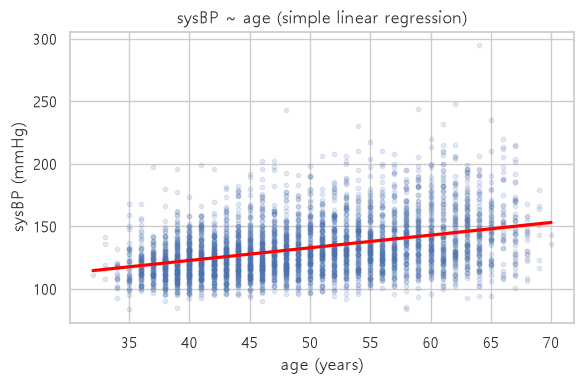

In [15]:
# age(설명변수) 하나로 sysBP(반응변수)를 예측하는 단순선형회귀
# TODO: "반응변수 ~ 설명변수" 공식으로 OLS 모형을 적합하세요 (.fit()까지)
model_simple = smf.ols("sysBP ~ age", data=df).fit()

# 회귀 결과 전체 요약표: 계수, 표준오차, t, p값, 95% CI, R^2 등
print(model_simple.summary())

# 핵심 값만 뽑아 보기
beta_age = model_simple.params["age"]          # age 기울기 계수
p_age    = model_simple.pvalues["age"]         # age 계수의 p값
ci_age   = model_simple.conf_int().loc["age"]  # age 계수의 95% 신뢰구간 [하한, 상한]
# TODO: 모형의 결정계수(R^2)를 꺼내세요 (model_simple 의 속성)
r2       = model_simple.rsquared

print(f"\nage 계수(기울기)  = {beta_age:.4f} mmHg / 1살")
print(f"age 계수 p값       = {p_age:.3e}")
print(f"age 계수 95% CI    = [{ci_age[0]:.4f}, {ci_age[1]:.4f}]")
print(f"R^2               = {r2:.4f}")

# 단순회귀에서 R^2 = (상관계수)^2 임을 직접 확인
r = df["age"].corr(df["sysBP"])
print(f"\ncorr(age, sysBP)  = {r:.4f},  r^2 = {r**2:.4f}  (== R^2)")

# 산점도 + 회귀직선으로 관계 시각화
plt.figure(figsize=(6, 4))
sns.regplot(x="age", y="sysBP", data=df,
            scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
plt.title("sysBP ~ age (simple linear regression)")
plt.xlabel("age (years)")
plt.ylabel("sysBP (mmHg)")
plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요):**

1. 본인이 얻은 `age` 계수는 얼마입니까? 문장으로 옮겨 보세요: "나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 ____ mmHg 높아진다."
: 수축기혈압(sysBP)은 평균 약 1.0128 mmHg 높아진다.

2. `age` 계수의 p값과 95% 신뢰구간을 인용하세요. 이 CI가 **0을 포함하는지** 확인하고, 그것이 "나이와 혈압 사이에 관계가 있다"는 주장과 어떻게 연결되는지 한 문장으로 설명하세요.
: 'age' 계수의 p값은 1.580e-157, 95% 신뢰구간은 [0.9416, 1.0839]이다. 이 CI는 0을 포함하지 않으므로 '나이와 혈압 사이에 관계가 없다'는 귀무가설이 기각되므로 '나이와 혈압 사이에 관계가 있다'라고 주장할 수 있다.

3. 본인의 $R^2$는 얼마입니까? `corr(age, sysBP)`의 제곱과 같은 값이 나왔나요? "$R^2$ = ____ 이므로, 나이만으로 sysBP 변동의 약 ____%를 설명한다"를 채워 쓰세요.
: $R^2$ = 0.1553 이므로, 나이만으로 sysBP 변동의 약 15.53%를 설명한다

**오개념 주의:**
- ❌ "$R^2$가 0.155니까 모형이 나쁘다" → $R^2$가 낮다고 관계가 없는 건 아닙니다. 계수의 p값($\approx 10^{-157}$)은 관계가 확실함을 보여줍니다. $R^2$는 설명력, p값은 관계의 존재 여부로 서로 다른 질문입니다.
- ❌ "나이가 혈압을 올린다(인과)" → 계수는 **연관(상관)**의 크기일 뿐, 이 관측 데이터만으로 인과를 증명하지 못합니다.
- ❌ 계수 단위 빼먹기 → 기울기의 단위는 **mmHg / 1살**입니다.


In [18]:
# 1.7 다중회귀 (범주형 포함)
# 연속형(age, BMI, totChol, glucose) + 범주형은 C(...)로 감싸 더미 처리
# statsmodels가 NaN 행을 자동 제외 → 실제 n이 줄어드는 점에 주의

# TODO: sysBP를 age, BMI, totChol, glucose(연속형) + male, currentSmoker, diabetes(범주형)로 설명하는 OLS
#       범주형 세 변수는 반드시 C(...)로 감쌀 것
model_multi = smf.ols(
    "sysBP ~age + BMI + totChol + glucose + C(male) + C(currentSmoker) + C(diabetes)",
    data=df).fit()

print(model_multi.summary())

# 결측 자동 제거로 실제 사용된 표본 크기 확인
print(f"\n전체 행수: {len(df)}")
print(f"다중회귀에 실제 사용된 n(nobs): {int(model_multi.nobs)}")   # TODO: model_multi에서 nobs 속성 사용
print(f"→ 결측으로 {len(df) - int(model_multi.nobs)}개 행 제외됨")

# 단순회귀(1.6) 대비 R² 상승 확인
print(f"\n단순회귀(age만) R²   = {model_simple.rsquared:.3f}")
print(f"다중회귀 R²          = {model_multi.rsquared:.3f}")   # TODO: model_multi의 R²
print(f"다중회귀 Adjusted R² = {model_multi.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     177.5
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          3.63e-228
Time:                        09:55:49   Log-Likelihood:                -16739.
No. Observations:                3828   AIC:                         3.349e+04
Df Residuals:                    3820   BIC:                         3.354e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                39.04

**Q. 다중회귀 결과를 확인하세요.**

1. `model_multi.nobs`는 전체 4,240에서 얼마로 줄었나요? **본인 값**을 적고, 왜 줄었는지 한 줄로 설명하세요.
: 3828로 줄었다. statsmodels는 formula에 쓰인 열 중 하나라도 NaN(결측)인 행을 통째로 제외하기 때문에 전체 4240행 보다 실제 쓰이는 n은 줄어든다.

2. `age` 계수가 단순회귀(1.6)와 다중회귀에서 달라졌나요? 어느 쪽이 더 크고 왜 그럴 수 있을까요? (다른 변수를 '통제'한다는 것과 연결해 설명하세요.)
: 단순회귀에서는 1.0128이었는데 다중회귀에서는 age의 계수값이 0.8183으로 줄어들었다. 단순회귀에서는 age가 다른 변수들의 영향까지 함께 반영하고 있었지만, 다중회귀에서는 다른 변수들의 영향을 제거(통제)한 후 age만의 순수한 효과를 추정했기 때문에 계수값이 더 작아진다.


In [19]:
# === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===
# 관점 전환: 1.6~statsmodels R²(in-sample, 해석) → 여기선 sklearn으로
# "처음 보는 test 데이터"에서의 예측 오차(RMSE·MAE)를 잰다.

# --- (1) 설계행렬 만들기 ---
target = "sysBP"
# TODO: 누수 방지 — sysBP(target)만 빼고 나머지를 설명변수 후보로. ____
feature_cols = [c for c in df.columns if c != target]

# 결측이 있으면 학습이 안 된다 → 설명변수+목표를 함께 놓고 결측 '행' 제거.
# TODO: 아래에서 결측 행을 통째로 제거하는 메서드를 채워라. ____
design = df[feature_cols + [target]].dropna()

# education만 원핫 인코딩(one-hot), 나머지는 숫자 그대로.
# TODO: education을 원핫하도록 인자를 채워라. ____
X = pd.get_dummies(design[feature_cols], columns=["education"], drop_first=True)
y = design[target]

print("사용한 행 수:", len(design), "/ 설명변수 개수:", X.shape[1])

# --- (2) train/test 분할 (재현 위해 random_state=MY_SEED) ---
# TODO: test 비율 0.2, random_state=MY_SEED 로 분할. ____
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MY_SEED
)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

# --- (3) 학습은 train에서만 ---
# TODO: train 데이터로만 적합. ____
lin = LinearRegression().fit(X_train, y_train)

# --- (4) 평가는 test에서만 ---
y_pred = lin.predict(X_test)
# TODO: RMSE = sqrt(MSE), MAE 를 test에서 계산. ____
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae  = metrics.mean_absolute_error(y_test, y_pred)

print(f"[예측 관점] test RMSE = {rmse:.3f} mmHg")
print(f"[예측 관점] test MAE  = {mae:.3f} mmHg")
print(f"RMSE - MAE 간격 = {rmse - mae:.3f}")

# --- (5) 해석 지표(in-sample R²)와 나란히 비교 ---
X_sm = sm.add_constant(X.astype(float))
ols_all = sm.OLS(y, X_sm).fit()
print(f"[해석 관점] in-sample R^2 = {ols_all.rsquared:.3f}")


사용한 행 수: 3658 / 설명변수 개수: 17
train: 2926  test: 732
[예측 관점] test RMSE = 11.119 mmHg
[예측 관점] test MAE  = 8.571 mmHg
RMSE - MAE 간격 = 2.548
[해석 관점] in-sample R^2 = 0.736


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **test RMSE = ____ mmHg** 와 **MAE = ____ mmHg** 를 적으세요. 두 값 중 어느 쪽이 항상 더 크며 왜인가요? 둘의 간격($\mathrm{RMSE} - \mathrm{MAE}$)은 무엇을 알려주나요?
: test RMSE = 11.119 mmHg, test MAE  = 8.571 mmHg이다. RMSE가 항상 MAE보다 크거나 같다. RMSE는 오차를 제곱하여 계산하므로 큰 오차에 더 큰 가중치를 주기 때문이다. 따라서 RMSE - MAE의 차이가 클수록 큰 예측 오차가 상대적으로 많이 존재함을 의미한다.

2. RMSE는 "예측이 평균 약 몇 mmHg 빗나간다"로 읽습니다. 본인 RMSE를 sysBP의 표준편차($\approx 22$ mmHg)와 비교하면 어느 정도인가요? 이 모델은 **전체 평균으로 찍는 것보다 나은가요?**
: RMSE는 11.119 mmHg로, sysBP의 표준편차(약 22 mmHg)의 절반 정도이다. 혈압의 전체 변동성에 비해 예측관점에서 오차가 비교적 작은 편이다. 따라서 이 모델은 전체 평균으로 찍는것보다 더 좋은 예측 성능을 보인다고 할 수 있다.

3. **$R^2$(in-sample)** 와 **test RMSE** 가 각각 답하는 질문을 한 문장씩 쓰세요. ($R^2$ → "데이터를 얼마나 잘 설명하나?", RMSE → "새 환자를 얼마나 잘 맞히나?") 이 구분이 리뷰 논문 Shmueli, *"To Explain or to Predict?"* 의 핵심입니다.
: R^2(in-sample) = 이 모델은 학습 데이터의 변동을 얼마나 잘 설명하는가?
  test RMSE = 이 모델은 새로운(처음 보는) 환자의 혈압을 얼마나 정확하게 예측하는가?

4. "$R^2$이 높으면 예측도 잘한다"가 항상 맞나요? $R^2$을 **학습에 쓴 데이터에서** 재면 왜 예측 성능의 증거가 되기 어려운지, train/test 분할이 왜 필요했는지 본인 말로 설명하세요.
:R^2은 학습에 쓴 데이터들을 얼마나 잘 설명하는지 알려주는 지표이지 새로운 test 셋의 예측 성능을 나타내기는 어렵다. 또한 예측 성능을 잘 설계하기 위해서는 본 적 없는 데이터에서 재야하며 이미 학습한 train 셋으로 잴 경우 예측 성능이 부풀려질 수 있다. 따라서 train/test  분할이 필요하다.


In [20]:
# 2-A. 진짜 관심사 TenYearCHD(0/1)를 '그냥' 선형회귀로 예측해 본다.
# (formula 방식은 결측이 있는 행을 자동으로 제외하고 적합한다.)
m_lpm = smf.ols("TenYearCHD ~ age + sysBP + BMI", data=df).fit()
pred = m_lpm.fittedvalues   # 각 사람에 대한 선형회귀 예측값

# TODO: 예측값의 최솟값과 최댓값을 출력하라.
print("예측값 min :", pred.min())
print("예측값 max :", pred.max())

# TODO: 예측값이 0보다 작은 사람 수, 1보다 큰 사람 수를 세어 출력하라.
n_below0 = int((pred < 0).sum())
n_above1 = int((pred > 1).sum())
print("0보다 작은 예측값을 받은 사람 수 :", n_below0)
print("1보다 큰 예측값을 받은 사람 수 :", n_above1)
print("적합에 실제로 쓰인 관측치 수 :", int(m_lpm.nobs))


예측값 min : -0.07071488414938024
예측값 max : 0.6461474980212303
0보다 작은 예측값을 받은 사람 수 : 89
1보다 큰 예측값을 받은 사람 수 : 0
적합에 실제로 쓰인 관측치 수 : 4221


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** 위 선형회귀의 예측값 중 0~1 범위를 벗어나는 사람이 있을지 없을지 한 줄로 먼저 적으세요.
: 예측값에 아무 제한이 없기 때문에 0~1 범위를 벗어나는 사람이 있을 것이다.

**(2) 본인 값 인용.** 실행해서 나온 본인 출력값을 적으세요.
- 예측값 min = -0.07071488414938024 , max = 0.6461474980212303
- 0보다 작은 예측값을 받은 사람 수 = 89 명
- 1보다 큰 예측값을 받은 사람 수 = 0 명

**(3) 판단.** 이 선형회귀 예측값을 그대로 "확률"이라 불러도 되는지, (2)의 min/max와 범위 이탈 인원 수를 근거로 판단하세요. 이탈한 사람이 0명이었더라도 age·sysBP·BMI가 더 극단적인 새 환자에서 항상 0~1에 머물 것이라 보장되는지도 함께 논하세요.
: 확률은 0과 1사이의 값을 가져야 하는데 min값에서 음수가 나오고, 0보다 작은 예측값을 받은 사람이 89명이 존재하므로 확률이라고 부를 수 없다. 또한 age·sysBP·BMI가 더 극단적인 새환자가 유입되면 선형회귀는 0보다 더 작거나, 1보다 더 큰 값을 예측할 수 있으므로 예측값이 항상 0과 1사이에 머문다고 보장할 수 없다.

**(4) 본인 언어로.** 이진 반응(0/1)을 예측할 때 선형회귀 대신 **로지스틱 회귀**가 왜 필요한지, 로지스틱이 예측값 범위 문제를 어떻게 다루는지 연결해 한 문단으로 설명하세요.
: 이진 결과를 예측할때 선형회귀를 사용하게 되면 예측값이 확률범위(0~1)를 벗어나게 된다. 반면 로지스틱 회귀는 시그모이드 함수를 이용하여 예측값이 항상 0과 1사이의 값이 되도록 하므로 이를 확률로 해석할 수 있어 이진반응 예측에는 로지스틱 회귀가 더 적합하다.


In [ ]:
# 2-B. 로지스틱 회귀 = Framingham Risk Score 엔진.  진짜 표적 TenYearCHD(0/1) 예측.
feat_log = ['age', 'male', 'sysBP', 'totChol', 'currentSmoker', 'glucose', 'BMI']
d_log = df[feat_log + ['TenYearCHD']].dropna()          # TODO: 결측 제거(dropna)
print("사용 표본 수:", len(d_log), "/ 전체:", len(df))

logit_model = smf.logit(
    "TenYearCHD ~ age + male + sysBP + totChol + currentSmoker + glucose + BMI",
    data=d_log).fit(disp=0)

# TODO: 계수에 np.exp() 를 취해 오즈비(odds_ratio) 열을 만들라.
or_table = pd.DataFrame({
    'coef': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),                               # TODO: np.exp(logit_model.params)
    'p_value': logit_model.pvalues,
})
print(or_table.round(4).to_string())

# 각 사람의 10년 발병 '확률' 예측 (2-A의 선형회귀와 달리 항상 0~1 안에 있는지 확인)
p_hat = logit_model.predict(d_log)
print("\n예측 확률 min / max :", round(float(p_hat.min()), 4), "/", round(float(p_hat.max()), 4))

# TODO: 
# _auc_score(정답 라벨, 예측 확률) 로 ROC-AUC 를 구하라.
auc_log = roc_auc_score(d_log['TenYearCHD'], p_hat)    # TODO: p_hat
print("ROC-AUC :", round(auc_log, 4))

사용 표본 수: 3828 / 전체: 4240
                 coef  odds_ratio  p_value
Intercept     -9.4547      0.0001   0.0000
age            0.0645      1.0666   0.0000
male           0.6402      1.8969   0.0000
sysBP          0.0169      1.0171   0.0000
totChol        0.0027      1.0027   0.0125
currentSmoker  0.3943      1.4834   0.0001
glucose        0.0074      1.0074   0.0000
BMI            0.0126      1.0127   0.2937

예측 확률 min / max : 0.0131 / 0.9382
ROC-AUC : 0.7366


**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 오즈비 읽기.** `odds_ratio`에서 **1보다 큰** 변수 2개와 **1에 가깝거나 p값이 유의하지 않은** 변수 1개를 값과 함께 적고, 각각 "한 단위 증가가 10년 발병 오즈를 몇 배로 바꾸는가"를 한 문장으로 해석하세요.
: odds_ratio가 1보다 큰 변수는 male, currentSmoker가 있고 1에 가깝거나 p값이 유의하지 않은 변수는 BMI가 있다. male이 0에서 1로 증가할 때 10년 발병 오즈는 약 1.8969배가 되고, currentSmoker가 0에서 1로 증가할 때 10년 발병 오즈는 1.4834배가 된다. BMI가 한 단위 증가하면 10년 발병 오즈는 1.0127배가 되지만 p값이 유의하지 않아 BMI의 영향이 통계적으로 유의하다고 보기 어렵다.

**(2) 범위 문제 해결 확인.** 로지스틱 예측 확률의 min/max는 얼마였나요(본인 값)? 2-A의 선형회귀 예측값(0~1 이탈)과 나란히 놓고, 로지스틱이 "확률" 요구를 어떻게 만족시키는지 본인 숫자로 설명하세요.
: 로지스틱 예측 확률 min / max : 0.0131 / 0.9382, 선형회귀 예측값 min / max : -0.07071488414938024 / 0.6461474980212303이다. 선형회귀의 min/max는 확률 0~1사이를 벗어나지만 로지스틱의 min/max는 확률 0~1사이를 만족시킨다.

**(3) 성능은 하나로 판단하지 않기.** 본인 ROC-AUC는 얼마이며 무작위(0.5)보다 나은가요? 이 값 하나로 "좋은 모델"이라 단정할 수 있는지, 없다면 무엇을 더 봐야 하는지(예: 양성 비율 불균형, 확률 캘리브레이션) 하나 이상 적으세요.
: ROC-AUC는 0.7366이며 무작위보다 높으므로 무작위보다 더 잘 구분하는 모델이라고 할 수 있다. 그러나 ROC-AUC 만으로 모델의 성능을 판단할 수는 없으며 양성 비율의 불균형 여부를 함께 평가해야한다.

**(4) 큰 그림 완성.** 지금 만든 로지스틱이 왜 "Framingham Risk Score의 엔진"인지, 이 과제가 강의(연속형 `sysBP`에서 멈춤)를 어떻게 이어서 완성하는지, 절차①(검정)→절차②(회귀)→표적 예측 흐름으로 2~3문장 정리하세요.
: 가설검정을 통해 변수와 결과 간의 관계가 통계적으로 유의한지 확인하고, 회귀모형을 이용해 여러 변수의 영향을 동시에 추정하였다. 이후 로지스틱 회귀를 사용하여 개인의 10년 심혈관질환 발생 확률을 예측하였으며 이 모형이 Framingham Risk Score의 핵심 엔진이 된다.

**문제 2-C. 이 모델, 어디에 쓸 것인가 — 본인 숫자로 결정하세요**

같은 병원에서 두 부서가 서로 다른 것을 부탁했습니다.

- (A) **설명**: "어떤 요인이 혈압과 연관되나? 무엇을 관리하라고 환자에게 말해야 하나?"
- (B) **예측**: "새 환자의 sysBP 값을 미리 맞히고 싶다. 오차가 얼마나 되나?"

본인의 다중회귀 $R^2$와 test RMSE를 **숫자로 인용**하며 답하세요.
*R^2 = 0.245/ test RMSE = 11.119 mmHg

**(1) 예측 먼저.** sysBP는 보통 90~180 mmHg 범위입니다. "$\pm$몇 mmHg 안에서 맞히면 임상적으로 쓸 만하다"는 본인 기준을 한 문장으로 적고, 본인 test RMSE와 비교하세요 — 기준을 통과하나요?
: $\pm$ 10 mmHg 이내라고 기준을 잡는다면, test RMSE 값인 11.119 mmHg는 이를 초과하므로 내가 설정한 기준을 통과하지 못한다.

**(2) 목적별 판단.**
- (A) 설명: 본인 $R^2$를 인용해 이 모델을 "어떤 요인이 혈압과 연관되는지" 말하는 근거로 쓸 수 있는지 판단하고, 써도 되는 이유와 조심할 이유를 각각 최소 하나씩 대세요.
: 본 모델의 다중회귀 R^2는 0.245로, sysBP 변동의 약 24.5%를 설명한다. 따라서 '어떤 요인이 혈압과 연관되는지'를 설명하는 근거로 사용할 수 있다. 하지만 약 75.5%의 변동은 모델에 포함되지 않은 다른 요인 등에 의해 설명되므로 이 모델만으로는 혈압을 결정하는 모든 요인을 설명한다고 해석할 수 없다.

- (B) 예측: 본인 test RMSE를 (1)의 기준과 나란히 놓고, 새 환자 혈압을 "맞힌다"고 내놓을 수 있는지 결정과 한계를 함께 쓰세요.
: 본 모델의 test RMSE는 11.119 mmHg로 내가 설정했던 허용기준인 $\pm$ 10 mmHg 보다 크다. 따라서 새 환자의 혈압을 맞춘다기보단 대략적으로 참고하는데에 사용할 수 있을 것이다. RMSE는 전체 환자의 전반적인 오차 크기를 나타내므로, 특정 환자에서는 실제 오차가 더 11.119 보다 더 크게 나올 수도 있다는 한계가 존재한다.

**(3) 리뷰 논문에 비추어.** Shmueli의 "To Explain or to Predict?"는 **설명을 잘하는 모델이 반드시 예측을 잘하는 것은 아니다**(설명력과 예측력은 다른 목표)라고 주장합니다. 본인의 $R^2$와 RMSE가 이 논지를 뒷받침하는지, 아니면 이 데이터에서는 애매한지 본인 관찰로 방어하세요.
: 본 모델의 R^2는 0.245로 혈압 변동의 약 24.5%를 설명하지만, test RMSE는 11.119 mmHg로 예측오차가 비교적 큰 편이다. 따라서 설명을 잘하는 모델이 반드시 좋은 예측 성능을 보이는 것은 아니라고 할 수 있다. 즉, 변수와 혈압의 연관성을 설명하는 것과 새로운 환자의 혈압을 예측하는 것은 서로 다른 목표라고 볼 수 있다. 


## 3. 결론

Framingham(n=4,240)으로 **추론 → 회귀 해석 → 예측 → 로지스틱**을 통과했습니다. 각 단계에서 **본인이 뽑은 값**을 근거로 정리하세요.

- **추론:** 내 95% CI `[ci_low, ci_high]` = [131.70, 133.00]을 "표본을 여러 번 다시 뽑는다면…"으로 풀어 쓰고, age 계수 p-value로 "나이가 sysBP와 관련 있나"를 판단하세요. 신뢰구간과 t검정이 같은 정보의 두 각도임을 한 문장으로
: 표본을 여러 번 다시 뽑는다면 매번 95% 신뢰구간을 만들 때 그 구간들의 약 95%는 실제 모집단의 sysBP를 포함하게 된다. age 계수 p-value는 1.580e-157으로 '나이와 혈압은 관계가 없다'라는 귀무가설을 기각하게된다. 95% 신뢰구간에 0이 포함되지 않으면 t검정에서도 유의수준 5%에서 귀무가설을 기각하는 동일한 결론을 얻는다.

- **회귀 해석:** `model_simple`의 age 계수를 **단위까지 붙여** 해석하고(나이 1살당 약 1.0128 mmHg), $R^2$ 값 0.1553이 "관련은 있지만 예측엔 부족"인지 판단하세요
: age 계수는 1.0128 mmHg / 1살로, 나이 1살당 sysBP는 약 1.0128 mmHg 증가한다. R^2은 0.1553으로 나이만으로 혈압 변동을 약 15.53% 설명한다는 의미로, 나이와 혈압은 관련은 있으나 예측력을 보여주진 않는다.

- **예측:** `rmse`, `mae`로 "이 오차가 혈압 스케일에서 쓸 만한가"를 판단하고, "유의하다(추론) ≠ 잘 맞힌다(예측)"를 한 문장으로
: RMSE = 11.119 mmHg이고 MAE  = 8.571 mmHg 이다. 예측 오차가 적지 않아 새 환자의 혈압을 정확하게 예측하는 데는 한계가 있다. 또한 통계적으로 유의하다고 해서 새로운 데이터를 잘 예측하는 모델이라는 뜻은 아니다.

- **로지스틱(§2-B):** 오즈비가 가장 컸던 변수와 내 ROC-AUC를 적고, 절차①(검정) → 절차②(회귀) → 위험 예측(= Framingham Risk Score 엔진)으로 이어지는 흐름을 요약하세요
: 오즈비가 가장 컸던 변수는 male이고 ROC-AUC는 0.7366으로 양호한 분류 성능을 보였다. 가장 먼저 각 위험요인이 심혈관 질환과 관련 있는지 검정하고, 로지스틱 회귀로 각 변수의 영향을 추정한 뒤, 이 모델을 이용하여 Framingham Risk Score 엔진에서 개인의 10년 심혈관질환 발생 위험을 예측하였다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(신뢰구간 의미, p-value 오개념, 유의성 vs 예측력 등) 1~3개도 함께
: p-value가 지표에서 그냥 0.000으로 나오면 유의하다라고만 판단했었는데 그 p-value의 정의인 '귀무가설이 참이라고 가정했을 때, 지금 표본처럼 또는 이보다 더 극단적인 결과가 나올 확률'이 항상 헷갈리는 것 같다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기**로만 쓰고 최종 판단은 본인이 합니다.

- **어디에 썼나** (문법 디버깅·개념 설명 등 구체적으로): 문법 맞았는지 확인, p-value 정의 설명

- **AI가 이 데이터엔 틀린 답을 준 사례** — 변수 계약(df·model_simple 등) 무시, 없는 열 이름, 실제 출력과 다른 숫자 단정 등. 그걸 **어떻게 알아채고 고쳤나요**(본인 출력값 대조 등): 틀린 답을 주진 않았다.

- **실제 대화 내역** 붙여넣기:

##첫 번째: {print(f"다중회귀 R² = {model_multi.rsquared:.3f}")   # TODO: model_multi의 R² 이거 코드 맞음?

응, 맞아.

print(f"다중회귀 R² = {model_multi.rsquared:.3f}")
model_multi.rsquared → 다중회귀모형의 결정계수 R
2
:.3f → 소수점 셋째 자리까지 출력

예를 들어 R
2
=0.23784라면:

다중회귀 R² = 0.238

로 출력돼.}

##두 번째: {p-value의 정의에 대해 아주아주 간단하게 설명해 그 다시뽑은 표본이 지금처럼 극단적 어쩌고..그걸로

가장 간단하게 쓰면 다음과 같다.

p-value는 귀무가설이 참이라고 가정했을 때, 지금 표본처럼 또는 이보다 더 극단적인 결과가 나올 확률이다.

조금 더 짧게 쓰면

p-value는 귀무가설이 참일 때 현재 표본만큼 극단적인 결과가 나올 확률이다.

이 표현이 통계학적으로도 가장 표준적인 정의다.}


- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은?
: sysBP를 오차범위 몇 기준에서 임상적으로 쓸만한지 판단할 때 AI가 대신할 수 없었던 나만의 판단이라고 생각한다.
